#Lab Tasks 04

##Lab Task 1: Build and Train a Self-Organising Map

The purpose of this task is to download a dataset from Kaggle or the UCI Machine
Learning repository and train a SOM on it.

**Dataset: Banknote Authentication (UCI).** This is the dataset the lab manual
describes — 1372 rows, 4 numerical features taken from wavelet transforms of
banknote photographs, no missing values, and one binary label (0 = genuine,
1 = forged). A copy is saved next to this notebook as
`banknote_authentication.csv` so the notebook runs without an internet
connection.

The SOM is trained **without the labels**. The labels are used only afterwards,
to colour the map and to measure how well the unsupervised map separated the two
classes — which is the point the manual makes: a map trained unsupervised can
still be used for classification.

###1. Loading the Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Palette used throughout this notebook
GENUINE_COLOR = "#2a78d6"   # blue  - class 0
FORGED_COLOR = "#eb6834"    # orange - class 1
EMPTY_COLOR = "#e6e5e0"     # grey  - neurons no sample claimed
INK = "#0b0b0b"
INK_SOFT = "#52514e"

banknotes = pd.read_csv("banknote_authentication.csv")
feature_names = ["variance", "skewness", "curtosis", "entropy"]

print("Shape:", banknotes.shape)
print("Missing values:", int(banknotes.isna().sum().sum()))
print("\nClass balance (0 = genuine, 1 = forged):")
print(banknotes["class"].value_counts().sort_index())
print("\nFeature summary:")
print(banknotes[feature_names].describe().round(2).to_string())

banknotes.head()

Shape: (1372, 5)
Missing values: 0

Class balance (0 = genuine, 1 = forged):
class
0    762
1    610
Name: count, dtype: int64

Feature summary:
       variance  skewness  curtosis  entropy
count   1372.00   1372.00   1372.00  1372.00
mean       0.43      1.92      1.40    -1.19
std        2.84      5.87      4.31     2.10
min       -7.04    -13.77     -5.29    -8.55
25%       -1.77     -1.71     -1.57    -2.41
50%        0.50      2.32      0.62    -0.59
75%        2.82      6.81      3.18     0.39
max        6.82     12.95     17.93     2.45


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


###2. Data Preprocessing

Two steps are needed before training.

**Splitting.** 80% of the rows are used to train the map and 20% are held back
to test it. The split is done first, so that nothing about the test rows can
leak into the scaling.

**Min-max scaling.** The SOM picks its winning neuron by Euclidean distance, so
a feature with a wide range would dominate that distance and the map would
organise itself almost entirely around that one feature. Here `skewness` spans
about 27 units while `entropy` spans about 11, so rescaling matters. Each
feature is mapped to 0–1, which is also the range the weights are initialised
in.

The minimum and maximum come from the **training set only** — using the full
dataset would leak information about the test rows into the model.

In [2]:
X = banknotes[feature_names].to_numpy(dtype="float64")
y = banknotes["class"].to_numpy(dtype=int)

# Shuffle and split 80 / 20
rng = np.random.default_rng(42)
order = rng.permutation(len(X))
split_at = int(0.8 * len(X))
train_idx, test_idx = order[:split_at], order[split_at:]

# Min-max scaling, fitted on the training rows only
X_min = X[train_idx].min(axis=0)
X_max = X[train_idx].max(axis=0)
X_scaled = (X - X_min) / (X_max - X_min)

X_train, y_train = X_scaled[train_idx], y[train_idx]
X_test, y_test = X_scaled[test_idx], y[test_idx]

print("Training set:", X_train.shape, "| Test set:", X_test.shape)
print("Train class balance:", np.bincount(y_train))
print("Test  class balance:", np.bincount(y_test))
print("\nScaled training range per feature:")
for i, name in enumerate(feature_names):
    print(f"  {name:<10}: {X_train[:, i].min():.2f} to {X_train[:, i].max():.2f}")

Training set: (1097, 4) | Test set: (275, 4)
Train class balance: [609 488]
Test  class balance: [153 122]

Scaled training range per feature:
  variance  : 0.00 to 1.00
  skewness  : 0.00 to 1.00
  curtosis  : 0.00 to 1.00
  entropy   : 0.00 to 1.00


###3. The SOM Implementation

The class follows the same competition / adaptation structure as the activities,
with three changes made for this task.

**1. The neighbourhood update is vectorised.** The activity version loops over
every neuron in Python for every sample. With 1097 training rows that would take
minutes per run. Computing the grid distances as one array makes it a few
seconds instead, and the arithmetic is identical.

**2. The Gaussian neighbourhood uses the squared distance.** The standard
neighbourhood function is

$$h = \exp\left(-\frac{d^2}{2\sigma^2}\right)$$

where `d` is the distance from the BMU **on the grid**. The manual's version
omits the square on `d`.

**3. Errors are recorded during training** so the learning curve can be plotted
and the map can be measured afterwards.

In [3]:
class SOM:
    def __init__(self, m, n, dim, learning_rate=0.5, sigma=None, random_state=None):
        self.m, self.n, self.dim = m, n, dim
        self.initial_learning_rate = learning_rate
        # Default neighbourhood radius: half the width of the map
        self.initial_sigma = sigma if sigma else max(m, n) / 2.0

        rng = np.random.default_rng(random_state)
        self.weights = rng.random((m, n, dim))

        # (m, n, 2) array holding the grid coordinates of every neuron,
        # so neighbourhood distances can be computed without a Python loop
        self._grid = np.stack(
            np.meshgrid(np.arange(m), np.arange(n), indexing="ij"), axis=-1)

        self.quantization_errors_ = []

    def _find_bmu(self, x):
        """Competition: return the grid position of the closest neuron."""
        distances = np.linalg.norm(self.weights - x, axis=-1)
        return np.unravel_index(np.argmin(distances), (self.m, self.n))

    def _update_weights(self, x, bmu, iteration, max_iter):
        """Adaptation: move the BMU and its neighbours towards x."""
        # Both the step size and the neighbourhood shrink as training proceeds
        learning_rate = self.initial_learning_rate * np.exp(-iteration / max_iter)
        sigma = self.initial_sigma * np.exp(-iteration / max_iter)

        # Distance from the BMU to every neuron, measured on the grid
        grid_distance = np.linalg.norm(self._grid - np.array(bmu), axis=-1)

        # Gaussian neighbourhood, cut off beyond the current radius
        influence = np.exp(-(grid_distance ** 2) / (2 * sigma ** 2))
        influence[grid_distance > sigma] = 0.0

        self.weights += influence[..., np.newaxis] * learning_rate * (x - self.weights)

    def train(self, X, num_iterations, random_state=None):
        """Online training: one sample at a time, in a new order each pass."""
        rng = np.random.default_rng(random_state)
        self.quantization_errors_ = []

        for iteration in range(num_iterations):
            for idx in rng.permutation(len(X)):
                x = X[idx]
                bmu = self._find_bmu(x)
                self._update_weights(x, bmu, iteration, num_iterations)
            self.quantization_errors_.append(self.quantization_error(X))

        return self

    def _distances_to_all(self, X):
        """Distance from every sample to every neuron -> (len(X), m*n)."""
        diff = self.weights[np.newaxis, :, :, :] - X[:, np.newaxis, np.newaxis, :]
        return np.linalg.norm(diff, axis=-1).reshape(len(X), -1)

    def bmu_indices(self, X):
        """The (row, column) of the winning neuron for every sample."""
        flat = np.argmin(self._distances_to_all(X), axis=1)
        return np.stack(np.unravel_index(flat, (self.m, self.n)), axis=1)

    def quantization_error(self, X):
        """Mean distance between a sample and its BMU. Lower is a tighter fit."""
        return self._distances_to_all(X).min(axis=1).mean()

    def topographic_error(self, X):
        """Fraction of samples whose best and second-best neurons are not
        neighbours on the grid. Lower means the topology is better preserved."""
        two_best = np.argsort(self._distances_to_all(X), axis=1)[:, :2]
        first = np.stack(np.unravel_index(two_best[:, 0], (self.m, self.n)), axis=1)
        second = np.stack(np.unravel_index(two_best[:, 1], (self.m, self.n)), axis=1)
        return (np.abs(first - second).max(axis=1) > 1).mean()

    def u_matrix(self):
        """Mean distance from each neuron's weights to its immediate
        neighbours'. High values mark boundaries between clusters."""
        u = np.zeros((self.m, self.n))
        for i in range(self.m):
            for j in range(self.n):
                total, count = 0.0, 0
                for di, dj in ((-1, 0), (1, 0), (0, -1), (0, 1)):
                    ni, nj = i + di, j + dj
                    if 0 <= ni < self.m and 0 <= nj < self.n:
                        total += np.linalg.norm(self.weights[i, j] - self.weights[ni, nj])
                        count += 1
                u[i, j] = total / count
        return u


print("SOM class defined.")

SOM class defined.


###4. Training the SOM

**Grid size.** A common rule of thumb is about `5 * sqrt(N)` neurons, which for
1097 training rows suggests roughly 165. A **12x12** grid gives 144 neurons —
close to that, and it leaves on average 7 to 8 samples per neuron, enough for
the majority vote in section 7 to mean something. A much larger map would give
almost one neuron per sample and would simply memorise the data.

**Learning rate 0.5** and **sigma 6.0** (half the map width, the class default)
are deliberately large starting values: early on the map should reorganise
freely, and both decay exponentially so later passes only fine-tune.

**30 iterations** is where the quantisation error levels off — section 5 shows
this.

In [4]:
som = SOM(m=12, n=12, dim=4, learning_rate=0.5, sigma=None, random_state=42)

print("Neurons          :", som.m * som.n)
print("Rule of thumb    : 5 * sqrt(%d) = %.1f neurons" % (len(X_train), 5 * np.sqrt(len(X_train))))
print("Initial sigma    :", som.initial_sigma)
print("Weight grid shape:", som.weights.shape)

som.train(X_train, num_iterations=30, random_state=42)

print("\nTraining complete.")
print("Quantization error: %.4f -> %.4f" % (som.quantization_errors_[0],
                                            som.quantization_errors_[-1]))

Neurons          : 144
Rule of thumb    : 5 * sqrt(1097) = 165.6 neurons
Initial sigma    : 6.0
Weight grid shape: (12, 12, 4)



Training complete.
Quantization error: 0.1720 -> 0.0954


###5. Training Progress: the Quantisation Error

The **quantisation error** is the mean distance between a sample and its winning
neuron, so it measures how tightly the map fits the data.

The curve falls unevenly at first. That is expected rather than a fault: while
`sigma` is still wide, every update drags a large patch of the map around, so a
pass can leave the map briefly worse fitted than before. As the neighbourhood
and the learning rate decay, the updates become local and the curve settles.

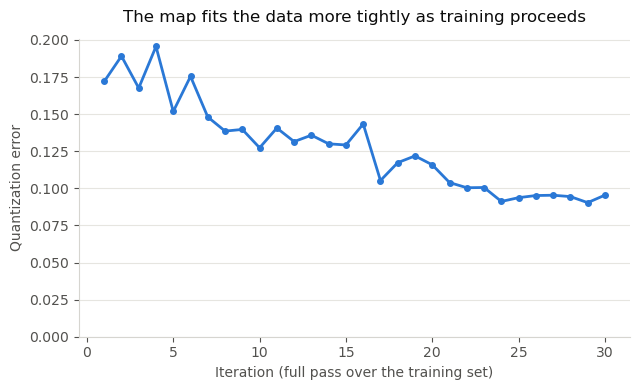

In [5]:
figure, axes = plt.subplots(figsize=(6.5, 4))

iterations = np.arange(1, len(som.quantization_errors_) + 1)
axes.plot(iterations, som.quantization_errors_, color=GENUINE_COLOR,
          linewidth=2, marker="o", markersize=4)

axes.set_xlabel("Iteration (full pass over the training set)", color=INK_SOFT)
axes.set_ylabel("Quantization error", color=INK_SOFT)
axes.set_title("The map fits the data more tightly as training proceeds",
               color=INK, fontsize=12, pad=12)
axes.set_ylim(bottom=0)

axes.spines["top"].set_visible(False)
axes.spines["right"].set_visible(False)
axes.spines["left"].set_color("#d6d5d0")
axes.spines["bottom"].set_color("#d6d5d0")
axes.tick_params(colors=INK_SOFT)
axes.yaxis.grid(True, color="#e6e5e0", linewidth=0.8)
axes.set_axisbelow(True)

plt.tight_layout()
plt.show()

###6. The U-Matrix

The **U-matrix** shows, for each neuron, the average distance from its weights
to those of its immediate neighbours. It is the standard way to read a SOM
without using any labels:

* **Light** areas are neurons whose neighbours are similar — the inside of a
  cluster.
* **Dark** ridges are neurons whose neighbours are very different — the
  boundary between clusters.

Because the SOM has not seen a single label, any structure visible here was
found in the features alone.

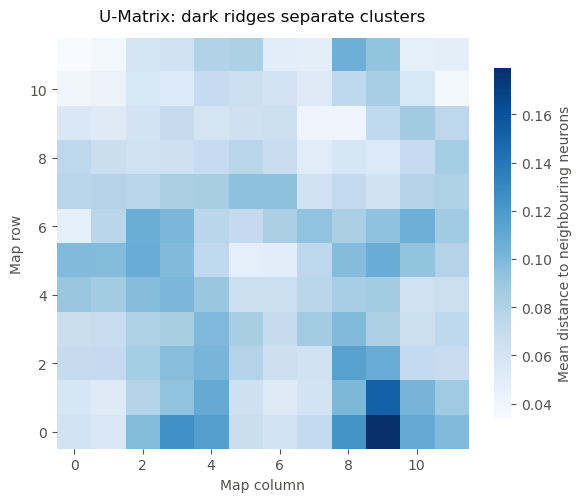

U-matrix range: 0.034 to 0.179


In [6]:
u_matrix = som.u_matrix()

figure, axes = plt.subplots(figsize=(6, 5))
image = axes.imshow(u_matrix, cmap="Blues", origin="lower")

colorbar = figure.colorbar(image, ax=axes, shrink=0.85)
colorbar.set_label("Mean distance to neighbouring neurons", color=INK_SOFT)
colorbar.ax.tick_params(colors=INK_SOFT)
colorbar.outline.set_visible(False)

axes.set_title("U-Matrix: dark ridges separate clusters", color=INK, fontsize=12, pad=12)
axes.set_xlabel("Map column", color=INK_SOFT)
axes.set_ylabel("Map row", color=INK_SOFT)
axes.tick_params(colors=INK_SOFT)
for spine in axes.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

print("U-matrix range: %.3f to %.3f" % (u_matrix.min(), u_matrix.max()))

###7. Labelling the Map

The map itself is unsupervised, but it can be turned into a classifier. Every
training sample is assigned to its BMU, and each neuron then takes the **majority
label** of the samples that landed on it.

Some neurons win no training sample at all. Those are filled in with the label of
the nearest labelled neuron on the grid, so that a test sample landing there
still gets an answer instead of being counted wrong by default.

In [7]:
train_bmus = som.bmu_indices(X_train)

# Count how many samples of each class landed on each neuron
class_counts = np.zeros((som.m, som.n, 2))
for (i, j), label in zip(train_bmus, y_train):
    class_counts[i, j, label] += 1

hit_counts = class_counts.sum(axis=2)
label_map = np.where(hit_counts > 0, np.argmax(class_counts, axis=2), -1)

used = int((hit_counts > 0).sum())
print("Neurons that won at least one training sample: %d of %d" % (used, som.m * som.n))
print("Samples per used neuron: min %d, max %d, mean %.1f" % (
    hit_counts[hit_counts > 0].min(), hit_counts.max(), hit_counts[hit_counts > 0].mean()))

# Fill the empty neurons from the nearest labelled neuron on the grid
labelled_positions = np.argwhere(label_map >= 0)
filled_label_map = label_map.copy()
for i in range(som.m):
    for j in range(som.n):
        if label_map[i, j] == -1:
            distances = np.linalg.norm(labelled_positions - np.array([i, j]), axis=1)
            ni, nj = labelled_positions[np.argmin(distances)]
            filled_label_map[i, j] = label_map[ni, nj]

# How pure is each neuron? (1.0 = every sample on it had the same label)
purity = np.divide(class_counts.max(axis=2), hit_counts,
                   out=np.zeros_like(hit_counts), where=hit_counts > 0)
print("Mean purity of the used neurons: %.4f" % purity[hit_counts > 0].mean())
print("Used neurons that are 100%% pure : %d of %d" % (
    int((purity[hit_counts > 0] == 1.0).sum()), used))

Neurons that won at least one training sample: 125 of 144
Samples per used neuron: min 1, max 45, mean 8.8
Mean purity of the used neurons: 0.9912
Used neurons that are 100% pure : 118 of 125


###8. The Class Map

Each neuron is drawn at its grid position, coloured by the class that claimed
it and sized by how many training samples it won. Grey squares are neurons no
sample reached.

The two classes occupy separate regions of the map rather than being mixed
together, which is what makes the majority-vote classifier in section 9 work.

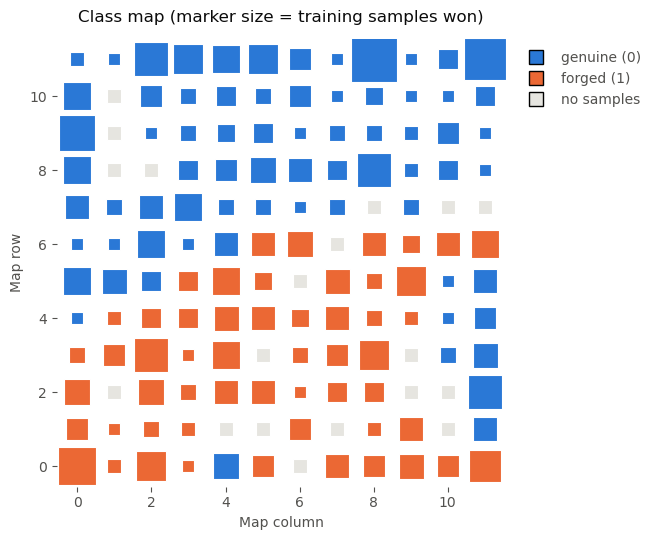

In [8]:
figure, axes = plt.subplots(figsize=(6.5, 5.5))

for i in range(som.m):
    for j in range(som.n):
        if hit_counts[i, j] == 0:
            axes.scatter(j, i, marker="s", s=90, color=EMPTY_COLOR,
                         edgecolor="white", linewidth=0.8)
        else:
            color = GENUINE_COLOR if label_map[i, j] == 0 else FORGED_COLOR
            size = 60 + 22 * hit_counts[i, j]
            axes.scatter(j, i, marker="s", s=size, color=color,
                         edgecolor="white", linewidth=0.8)

# A legend built by hand, because the marks above are drawn one at a time
from matplotlib.lines import Line2D
legend_items = [
    Line2D([0], [0], marker="s", color="none", markerfacecolor=GENUINE_COLOR,
           markersize=10, label="genuine (0)"),
    Line2D([0], [0], marker="s", color="none", markerfacecolor=FORGED_COLOR,
           markersize=10, label="forged (1)"),
    Line2D([0], [0], marker="s", color="none", markerfacecolor=EMPTY_COLOR,
           markersize=10, label="no samples"),
]
axes.legend(handles=legend_items, frameon=False, labelcolor=INK_SOFT,
            loc="upper left", bbox_to_anchor=(1.01, 1.0))

axes.set_title("Class map (marker size = training samples won)",
               color=INK, fontsize=12, pad=12)
axes.set_xlabel("Map column", color=INK_SOFT)
axes.set_ylabel("Map row", color=INK_SOFT)
axes.set_xticks(range(0, som.n, 2))
axes.set_yticks(range(0, som.m, 2))
axes.tick_params(colors=INK_SOFT)
axes.set_aspect("equal")
for spine in axes.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

###9. Component Planes

A component plane shows one feature's weight across the whole map. Read together
with the class map, they say **which measurements** drove the separation: if a
feature's plane looks like the class map, that feature is doing the work; if it
looks flat or unrelated, it is not.

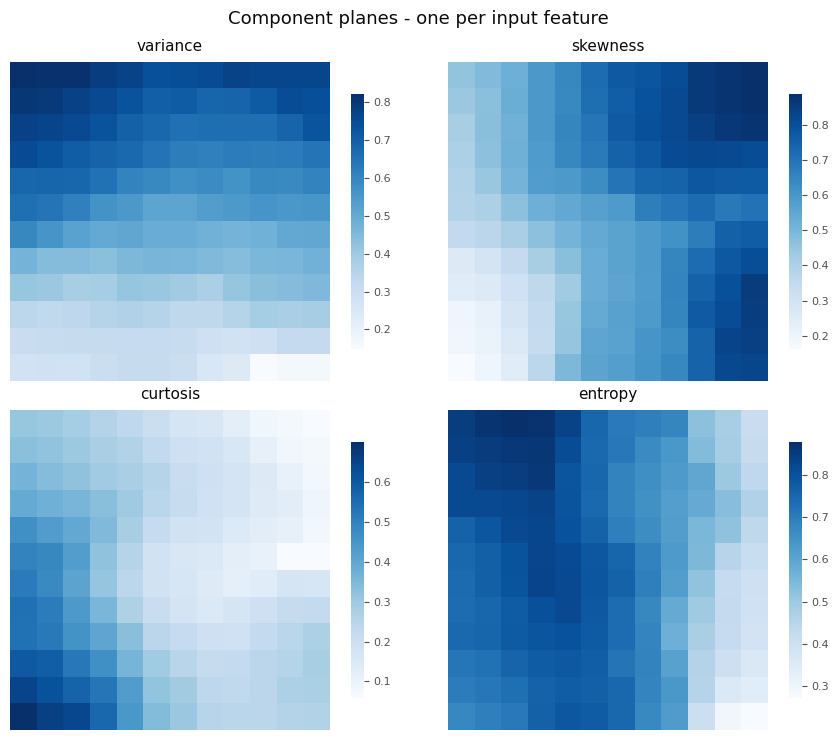

In [9]:
figure, axes_grid = plt.subplots(2, 2, figsize=(9, 7.5))

for index, (name, axes) in enumerate(zip(feature_names, axes_grid.ravel())):
    plane = som.weights[:, :, index]
    image = axes.imshow(plane, cmap="Blues", origin="lower")
    axes.set_title(name, color=INK, fontsize=11, pad=8)
    axes.set_xticks([])
    axes.set_yticks([])
    for spine in axes.spines.values():
        spine.set_visible(False)
    bar = figure.colorbar(image, ax=axes, shrink=0.8)
    bar.ax.tick_params(colors=INK_SOFT, labelsize=8)
    bar.outline.set_visible(False)

figure.suptitle("Component planes - one per input feature",
                color=INK, fontsize=13, y=0.98)
plt.tight_layout()
plt.show()

###10. Evaluation on the Test Set

The held-out rows are now pushed through the map: each one is matched to its
BMU, and the label attached to that neuron in section 7 becomes the prediction.
These rows took no part in training or in the scaling.

In [10]:
test_bmus = som.bmu_indices(X_test)
predictions = np.array([filled_label_map[i, j] for i, j in test_bmus])

accuracy = (predictions == y_test).mean()
print("Test accuracy: %.4f  (%d of %d correct)" % (
    accuracy, int((predictions == y_test).sum()), len(y_test)))

confusion = pd.crosstab(
    pd.Series(y_test, name="actual"),
    pd.Series(predictions, name="predicted"),
)
print("\nConfusion matrix:")
print(confusion.to_string())

# Per-class precision and recall, worked out from the confusion matrix
print("\nPer class:")
for cls, cls_name in ((0, "genuine"), (1, "forged")):
    true_positive = int(((predictions == cls) & (y_test == cls)).sum())
    predicted_positive = int((predictions == cls).sum())
    actual_positive = int((y_test == cls).sum())
    precision = true_positive / predicted_positive if predicted_positive else 0.0
    recall = true_positive / actual_positive if actual_positive else 0.0
    print(f"  {cls_name:<8}: precision {precision:.4f} | recall {recall:.4f}")

print("\nMap quality:")
print("  Quantization error (train): %.4f" % som.quantization_error(X_train))
print("  Quantization error (test) : %.4f" % som.quantization_error(X_test))
print("  Topographic error  (train): %.4f" % som.topographic_error(X_train))

Test accuracy: 0.9891  (272 of 275 correct)

Confusion matrix:
predicted    0    1
actual             
0          152    1
1            2  120

Per class:
  genuine : precision 0.9870 | recall 0.9935
  forged  : precision 0.9917 | recall 0.9836

Map quality:
  Quantization error (train): 0.0954
  Quantization error (test) : 0.0932
  Topographic error  (train): 0.0246


##Report

*The manual asks for a short report covering the four points below.*

###1. Data preprocessing steps

The Banknote Authentication dataset (UCI) has 1372 rows, 4 continuous features
taken from wavelet transforms of banknote photographs, and a binary label. It
needed no cleaning — there are no missing values and every feature is already
numeric — so preprocessing was two steps.

**Splitting first.** The rows were shuffled with a fixed seed and split 80 / 20
into 1097 training and 275 test rows. The split was done *before* scaling so
that no information about the test rows could reach the model.

**Min-max scaling to 0–1.** The SOM chooses its winning neuron by Euclidean
distance, so a feature with a wider range contributes more to that distance
simply because of its units. `skewness` spans roughly 27 units and `entropy`
roughly 11, so without scaling the map would have organised itself largely
around `skewness`. The minimum and maximum were taken from the training rows
only. 0–1 also matches the range the weights are initialised in, so no neuron
starts far outside the data.

The labels were **not** used at any point in training. They appear only when
colouring the map and measuring accuracy.

###2. Model architecture and rationale for the hyperparameters

| Choice | Value | Why |
|---|---|---|
| Grid | 12 x 12 = 144 neurons | The `5 * sqrt(N)` rule of thumb suggests ~165 for 1097 rows. 144 is close to that and leaves 7–8 samples per neuron on average, so the per-neuron majority vote is based on more than one or two points. A much larger map approaches one neuron per sample and just memorises the data. |
| Input dimension | 4 | One weight per feature. |
| Learning rate | 0.5, decaying | Large enough that the map can reorganise freely early on; the exponential decay means later passes only fine-tune. |
| Sigma (neighbourhood) | 6.0, decaying | Half the map width. Starting wide lets whole regions move together, which is what produces a smooth, ordered map; it then shrinks so late updates are local. Too small a neighbourhood from the start risks dead neurons and an unordered map. |
| Iterations | 30 | The quantisation error curve flattens by roughly iteration 25, so more passes cost time without improving the fit. |
| Neighbourhood function | Gaussian on squared grid distance | The standard `exp(-d^2 / 2*sigma^2)`. |

The architecture is a single competitive layer: a 12 x 12 lattice where every
neuron is connected to all 4 inputs and holds its own 4-value weight vector.

###3. Training process and evaluation metrics

Training was **online**: one sample at a time, in a fresh random order each pass.
For each sample the BMU is found by Euclidean distance, then the BMU and its
neighbours are moved towards that sample by an amount set by the Gaussian
neighbourhood, the current learning rate, and the neuron's grid distance from
the BMU.

Three metrics were used, two of which need no labels:

* **Quantisation error** — mean distance from a sample to its BMU; how tightly
  the map fits the data. It fell from **0.1720** to **0.0954** over the 30
  iterations, and **0.0932** on the test rows, essentially the same as on the
  training rows, so the map generalises rather than having memorised.
* **Topographic error** — the fraction of samples whose best and second-best
  neurons are not adjacent on the grid; how well the map preserved the topology
  of the input space. **0.0246**, i.e. about 2.5% — below the 5% usually treated
  as a well-ordered map.
* **Classification accuracy** — after labelling each neuron by the majority
  class of the training samples that landed on it, the held-out rows were
  classified by their BMU's label: **0.9891**, 272 of 275 correct.

###4. Observations and insights

**An unsupervised map separated the classes.** The SOM was never shown a label,
yet the class map shows genuine and forged notes occupying distinct regions
rather than being interleaved, and majority-vote labelling classifies held-out
notes at almost 99%. The neurons are also almost pure: **118 of the 125** that
won any sample won samples of one class only, and mean purity across them is
**0.9912**. So the majority vote is rarely a close call — most neurons are
unanimous. This is the point the manual makes about applying an unsupervised map
to a labelled problem.

**The U-matrix agrees, though less sharply than the class map.** Neurons that
sit next to a neuron of the other class have a mean inter-neuron distance of
**0.0893**, against **0.0735** for neurons in the interior of a class region —
about 1.2x higher. So the label boundary does fall on raised ground in a map
built without labels, which says the structure is really in the features. It is
a moderate rise rather than a sharp ridge, and the single darkest cell in the
U-matrix is not on the class boundary at all: it marks a sparse pocket inside
the forged region.

**125 of 144 neurons won a training sample.** The 19 empty ones are scattered
across the map rather than concentrated in one place: 7 of them lie between the
two class regions, and the other 12 fall inside a region where the data is thin.
Unclaimed units are a normal outcome whenever a map has more neurons than the
data has dense areas, not a fault. They do have to be handled at prediction
time, which is why an empty neuron inherits the label of the nearest labelled
one — without that, 6 of the 275 test notes would land on a neuron with no
answer attached.

**The learning curve is not monotonic.** The quantisation error rises on several
early passes. While sigma is wide, one sample drags a large patch of the map
with it, so fitting one region can briefly worsen another. It settles once the
neighbourhood shrinks — a property of the wide-neighbourhood phase, not a bug.

**Limitation.** Accuracy here is measured on a map labelled with the same
training data, and the classes in this dataset are close to linearly separable,
so 99% should not be read as a hard result for SOMs in general. The honest
claim is narrower: the *unsupervised* map recovered the class structure without
being told it.

#End!